In [28]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt 

In [29]:
df = pd.read_csv(r"C:\Users\Ittikorn\OneDrive\Desktop\Ai\Machinelearning\ssswork\Dataset\loan.csv")

In [30]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [31]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [32]:
df.info() # Garbage Value มาในรูปของ Object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [33]:
a = ["Loan_ID","Property_Area","Gender","Married","Education",]
df = df.drop(a,axis=1)

In [34]:
df.isnull().sum() / df.shape[0]*100 # ต้องไม่เกิน 15 % 

Dependents           2.442997
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Loan_Status          0.000000
dtype: float64

In [35]:
df.head()

,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,0,No,5849,0.0,NaN,360.0,1.0,Y
1,1,No,4583,1508.0,128.0,360.0,1.0,N
2,0,Yes,3000,0.0,66.0,360.0,1.0,Y
3,0,No,2583,2358.0,120.0,360.0,1.0,Y
4,0,No,6000,0.0,141.0,360.0,1.0,Y


In [36]:
#Finding Duplicate
df.duplicated().sum()

1

In [37]:
# Garbage Value
for i in df.select_dtypes(include="object").columns :
    print(df[i].value_counts())
    

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [38]:
# desctiptive statistics
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [39]:
df.describe(include='object')

,Dependents,Self_Employed,Loan_Status
count,599,582,614
unique,4,2,2
top,0,No,Y
freq,345,500,422


In [40]:
df.isnull().sum() # data missing

Dependents           15
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Loan_Status           0
dtype: int64

In [41]:
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'])
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [42]:
df.head()

,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome
0,0.0,No,5849,0.0,128.0,360.0,1.0,Y,5849.0
1,1.0,No,4583,1508.0,128.0,360.0,1.0,N,6091.0
2,0.0,Yes,3000,0.0,66.0,360.0,1.0,Y,3000.0
3,0.0,No,2583,2358.0,120.0,360.0,1.0,Y,4941.0
4,0.0,No,6000,0.0,141.0,360.0,1.0,Y,6000.0


In [43]:
# Check cloumn ไหนพัง
df.select_dtypes(include='object').columns

Index(['Self_Employed', 'Loan_Status'], dtype='object')

In [44]:
df['LoanAmount'] = np.log1p(df['LoanAmount'])
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [45]:
df.head()

,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome
0,0.0,0.0,5849,0.0,4.859812,360.0,1.0,1,5849.0
1,1.0,0.0,4583,1508.0,4.859812,360.0,1.0,0,6091.0
2,0.0,1.0,3000,0.0,4.204693,360.0,1.0,1,3000.0
3,0.0,0.0,2583,2358.0,4.795791,360.0,1.0,1,4941.0
4,0.0,0.0,6000,0.0,4.955827,360.0,1.0,1,6000.0


In [46]:
x = df.drop(['Loan_Status','ApplicantIncome','CoapplicantIncome'],axis=1)
y = df['Loan_Status']

In [47]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=0)


In [ ]:
# Cross Valization Randomized หาค่า 'n_estimators':, 'min_samples_split': , 'min_samples_leaf': , 'max_depth':  ที่ดีที่สุด
'''
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],  #  ต้องเป็น list
    'max_depth': [10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

random = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=20,cv=5,scoring='recall',n_jobs=-1,random_state=42)

random.fit(x_train, y_train)

print(random.best_params_)

'''

"\nfrom sklearn.model_selection import RandomizedSearchCV\nparam_dist = {\n    'n_estimators': [100, 200, 300, 500],  # ✅ ต้องเป็น list\n    'max_depth': [10],\n    'min_samples_split': [2, 5, 10, 20],\n    'min_samples_leaf': [1, 2, 4, 8]\n}\n\nrf = RandomForestClassifier(class_weight='balanced', random_state=42)\n\nrandom = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=20,cv=5,scoring='recall',n_jobs=-1,random_state=42)\n\nrandom.fit(x_train, y_train)\n\nprint(random.best_params_)\n\n"

In [49]:
model = RandomForestClassifier(n_estimators=300,max_depth=5,min_samples_split=10,min_samples_leaf=5,max_features='sqrt',class_weight='balanced')
model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=300)

In [50]:
#y_pred = model.predict(x_test) Thershould 
y_prob = model.predict_proba(x_test)[:,1]
y_pred = (y_prob > 0.6).astype(int)

In [51]:
from sklearn.metrics import classification_report , confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.61      0.54        33
           1       0.84      0.77      0.80        90

    accuracy                           0.72       123
   macro avg       0.66      0.69      0.67       123
weighted avg       0.75      0.72      0.73       123



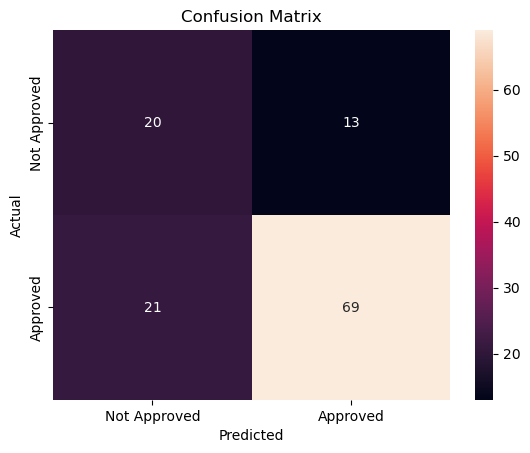

In [52]:
import seaborn as sns 
# Show Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Not Approved','Approved'],
            yticklabels=['Not Approved','Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [53]:
# หา Feature ตัวปัญหา
import pandas as pd
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': x.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp)

            feature  importance
4    Credit_History    0.593792
5       TotalIncome    0.176923
2        LoanAmount    0.133236
0        Dependents    0.038380
3  Loan_Amount_Term    0.034097
1     Self_Employed    0.023572


In [54]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)